# Computer Vision, Assignment 3: Epipolar Geometry

In this assignment, you will study epipolar geometry. 
You will use the fundamental matrix and the essential matrix for simultaneously reconstructing the 3D structure and the camera motion from two images.

Please see Canvas for detailed instructions on what is expected for a passing/higher grade.
All computer exercises that are not marked **OPTIONAL** are ``mandatory'' in the sense described on Canvas.


### Submission Requirements:
Your final lab submission should include:
1. Your edited **notebook file** (`.ipynb`).
2. An **HTML printout** of the executed notebook with all outputs visible: File → Save and export Notebook As → HTML
3. A **pdf report** containing answers to the theoretical exercises (see separate document).

In [1]:
# for creating responsive plots
%matplotlib widget  

import cv2
import matplotlib.image as mpimg
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import scipy.io

from supplied import pflat, plot_camera, rital, psphere

# The Fundamental Matrix

#### *Theoretical exercises 1-4* (see pdf)

## Computer Exercise 1
<figure align="center">
    <img alt="left" src="data/kronan1.JPG" width="250px">
&nbsp; &nbsp; &nbsp; &nbsp;
    <img alt="right" src="data/kronan2.JPG" width="250px">
    <figcaption>Figure1. kronan1.jpg and kronan2.jpg</figcaption>
</figure>

In this exercise you will compute the fundamental matrix for the two images above, showing a part of the fort Kronan in Gothenburg. The calibration matrix $K$ is assumed to be unknown. The file `compEx1data.mat` contains a cell `x` with matched points for the two images.

### Task 1.1
Compute normalization matrices $N_1$ and $N_2$. These matrices should subtract the mean and re-scale using the standard deviation, as in assignment 2.
Normalize the image points of the two images with $N_1$ and $N_2$, respectively.

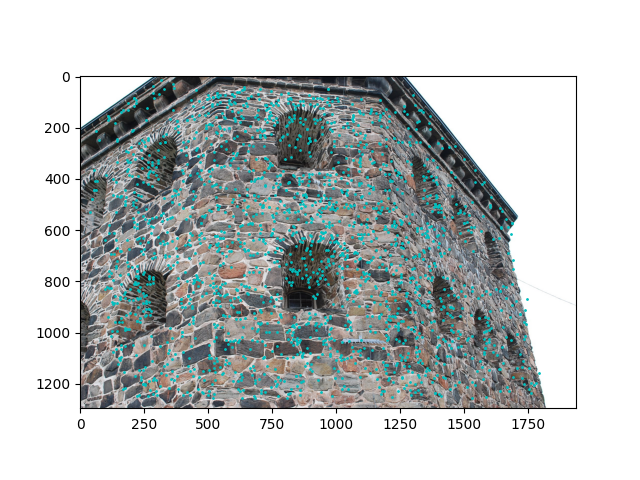

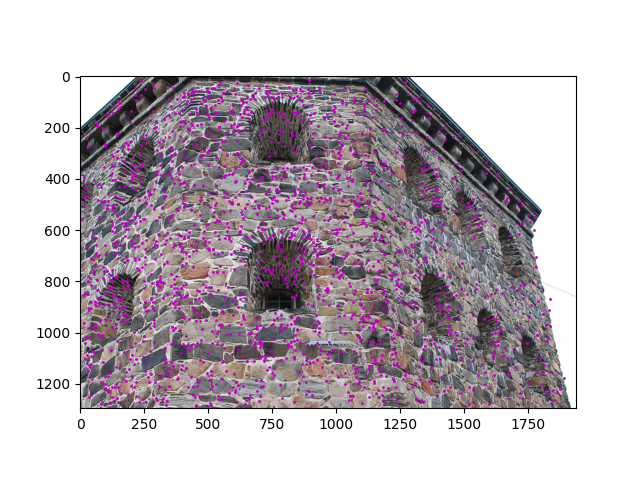

-----------------------CAMERA 1-------------------------
The mean that is used to normalize the x coordinate is 851.2593625498008
The mean that is used to normalize the y coordinate is 667.675876494024
The standard deviation that is used to normalize the x coordinate is 420.16769192483406
The standard deviation that is used to normalize the y coordinate is 332.98670637196153
mean of x_norm x = -7.077118882072711e-18
mean of x_norm y = -2.618533986366903e-16
standard deviation of x_norm x is = 1.0
standard deviation of x_norm y is = 1.0


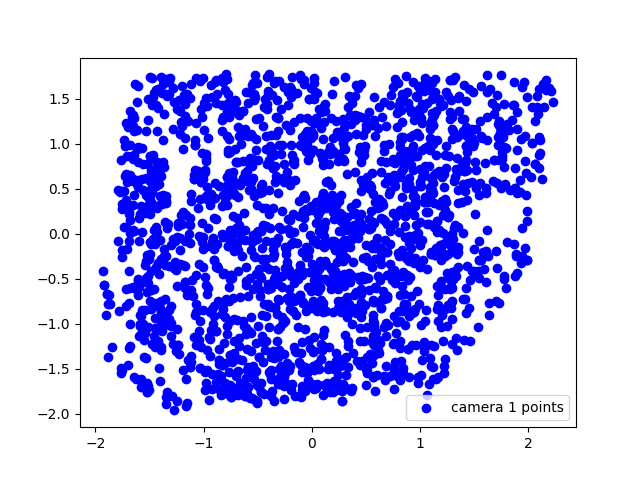

-----------------------CAMERA 2-------------------------
The mean that is used to normalize the x coordinate is 760.4540239043824
The mean that is used to normalize the y coordinate is 664.1767231075696
The standard deviation that is used to normalize the x coordinate is 454.03769079569935
The standard deviation that is used to normalize the y coordinate is 346.1775864736366
mean of x_norm x = 1.5569661540559965e-16
mean of x_norm y = 5.378610350375261e-16
standard deviation of x_norm x is = 1.0
standard deviation of x_norm y is = 1.0000000000000002


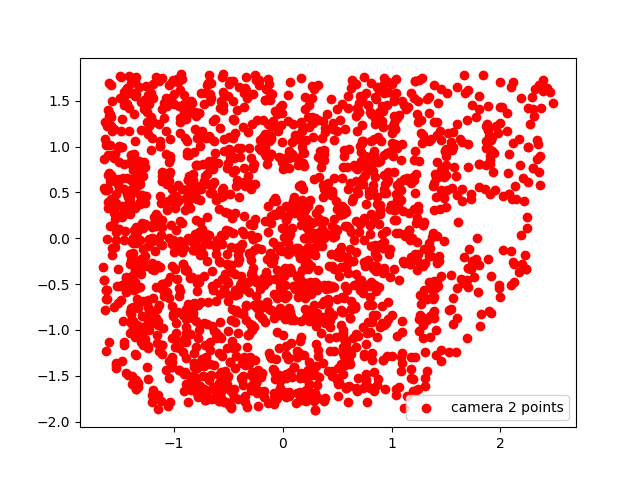

In [2]:
# ------ Your code here ------
data = sp.io.loadmat('data/compEx1data.mat')
x = data['x'] # matched points between the two images
p1 = x[0][0] 
p2 = x[1][0]

#---- image 1-----#
fig = plt.figure()
ax = fig.add_subplot()

img1 = mpimg.imread('data/kronan1.JPG')
ax.imshow(img1)
ax.scatter(p1[0], p1[1], color='c', s=1)
plt.show()
#---- image 2-----#
fig2 = plt.figure()
ax2 = fig2.add_subplot()

img2 = mpimg.imread('data/kronan2.JPG')
ax2.imshow(img2)
ax2.scatter(p2[0], p2[1], color='m', s=1)
plt.show()
# Compute N1 and N2

mean_xx = np.mean(p1[0], axis=0)
mean_xy = np.mean(p1[1], axis=0)
std_xx = np.sqrt(np.var(p1[0]))
std_xy = np.sqrt(np.var(p1[1]))

N1 = np.array([[1/std_xx, 0, -mean_xx/std_xx],
     [0, 1/std_xy, -mean_xy/std_xy],
     [0, 0, 1]
])
#N1 = np.eye(3)
print('-----------------------CAMERA 1-------------------------')
print(f'The mean that is used to normalize the x coordinate is {mean_xx}')
print(f'The mean that is used to normalize the y coordinate is {mean_xy}')
print(f'The standard deviation that is used to normalize the x coordinate is {std_xx}')
print(f'The standard deviation that is used to normalize the y coordinate is {std_xy}')

p1_norm = np.matmul(N1, p1)
print(f'mean of x_norm x = {np.mean(p1_norm[0])}')
print(f'mean of x_norm y = {np.mean(p1_norm[1])}')
print(f'standard deviation of x_norm x is = {np.sqrt(np.var(p1_norm[0]))}')
print(f'standard deviation of x_norm y is = {np.sqrt(np.var(p1_norm[1]))}')

fig20 = plt.figure()
ax20 = fig20.add_subplot()
ax20.scatter(p1_norm[0], p1_norm[1], color='b', label='camera 1 points')
plt.legend()
plt.show()



mean_xx = np.mean(p2[0], axis=0)
mean_xy = np.mean(p2[1], axis=0)
std_xx = np.sqrt(np.var(p2[0]))
std_xy = np.sqrt(np.var(p2[1]))

N2 = np.array([[1/std_xx, 0, -mean_xx/std_xx],
     [0, 1/std_xy, -mean_xy/std_xy],
     [0, 0, 1]
])
#N2 = np.eye(3)
print('-----------------------CAMERA 2-------------------------')
print(f'The mean that is used to normalize the x coordinate is {mean_xx}')
print(f'The mean that is used to normalize the y coordinate is {mean_xy}')
print(f'The standard deviation that is used to normalize the x coordinate is {std_xx}')
print(f'The standard deviation that is used to normalize the y coordinate is {std_xy}')
p2_norm = np.matmul(N2, p2)
print(f'mean of x_norm x = {np.mean(p2_norm[0])}')
print(f'mean of x_norm y = {np.mean(p2_norm[1])}')
print(f'standard deviation of x_norm x is = {np.sqrt(np.var(p2_norm[0]))}')
print(f'standard deviation of x_norm y is = {np.sqrt(np.var(p2_norm[1]))}')

fig30 = plt.figure()
ax30 = fig30.add_subplot()
ax30.scatter(p2_norm[0], p2_norm[1], color='r',label='camera 2 points')
plt.legend()
plt.show()

# Normalize the image points


#print(N1)

### Task 1.2
Set up the matrix $M$ in the eight point algorithm (8 is the minimum number of points, you should use all the points here), and solve the homogeneous least squares system using SVD. 
Check that the minimum singular value and $||Mv||$ are both small. Construct the $3 \times 3$ matrix $\tilde F$ from the solution $v$. This matrix should approximately satisfy $\tilde x_2^T \tilde F \tilde x_1 = 0$, where $\tilde x_j$ are normalized image points. Write the code as a function which would be useful later. 

In [28]:
def estimate_F_DLT(x1s, x2s):
    '''
    x1s and x2s contain matching points
    x1s - 2D image points in the first image in homogenous coordinates (3xN)
    x2s - 2D image points in the second image in homogenous coordinates (3xN)
    '''
    nr_of_points = np.size(x1s[0])
    M = np.zeros((nr_of_points, 9))
    #M = np.zeros((2008, 9))
    for i in range(len(x1s[0])):
        x1, y1, z1 = x2s[:,i]
        
        x2, y2, z2 = x1s[:,i]


        M[i,:] = [x1*x2,  x1*y2,  x1*z2, 
                  y1*x2,  y1*y2,  y1*z2,  
                  z1*x2,  z1*y2,  z1*z2
                ]

    U, S, Vt = np.linalg.svd(M)

    F = Vt[-1,:].reshape(3,3)
    smallest_eig_val =S[-1]
    Mv = np.linalg.norm(M @ Vt[-1,:])
    print(f'|Mv| = {Mv}')
    print(f'smallest singular value = {smallest_eig_val}')

    return F
    
    


You must also make sure that $\det(\tilde{F}) = 0$ for your solution. Make a separate function that explicitly enforces the constraint, as this will be convenient for you later.

In [4]:
def enforce_fundamental(F_approx):
    '''
    F_approx - Approximate Fundamental matrix (3x3)
    '''
    det = np.linalg.det(F_approx)
    print(f'determinant is {det}')
    try:
        assert det == 0, "determinant is not zero!"
    except AssertionError as e:
        print("AssertionError:", e)



Estimate $\tilde{F}$ and check that the epipolar constraints $\tilde{x}_2^T \tilde{F} \tilde{x}_1 = 0$ are roughly fulfilled.


In [5]:
# ------ Your code here ------

# Estimate F_tilde 
F_tilde = estimate_F_DLT(p1_norm,p2_norm)
Uf, Sf, Vts = np.linalg.svd(F_tilde)
S_matrix = np.array([[Sf[0], 0, 0],
                     [0, Sf[1], 0],
                     [0, 0, 0]])

F_tilde_det = Uf @ S_matrix @ Vts
enforce_fundamental(F_tilde_det) 

# Check epipolar constraints
res = 0
for j in range(len(p1[0])):
    x2T = p2_norm[:,j]
    x1 = p1_norm[:,j]
    res += np.abs(np.matmul(np.matmul(x2T, F_tilde_det), x1))
    const = np.matmul(np.matmul(x2T, F_tilde_det), x1)
    #print(const)
print(f'average value of x2^T * F * x1 = {res/len(p1[0])}')


|Mv| = 0.04965450019510686
smallest singular value = 0.04965450019510705
determinant is -1.1651056220841274e-18
AssertionError: determinant is not zero!
average value of x2^T * F * x1 = 0.0007158981329758858


### Task 1.3



Compute the un-normalized fundamental matrix $F$ (using the formula from exercise 4) and the epipolar lines $l = F x_1$. Pick 20 points in the second image at random and plot these in the same figure as the image.
Also plot the corresponding epipolar lines in the same image using the function `rital`. Verify that the points are close to the corresponding epipolar lines.





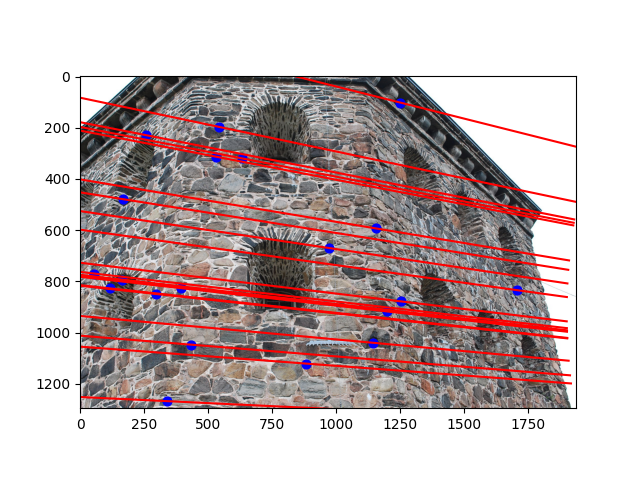

distance beween point 1 and line 1 = 0.0015210735099886463


In [6]:
# ------ Your code here ------ 
import random
# N1 normalizing matrix for p1s
# N2 normalizing matrix for p2s

# Compute un-normalized F
F = N2.T @ F_tilde_det @ N1

# Compute epipolar lines
nr_random_points = 20
random_points = random.sample(range(len(p2[0])), nr_random_points)
r = random_points


# Visualize epipolar lines and corresponding points and check that epipolar constraints roughly fulfilled
fig4 = plt.figure()
ax4 = fig4.add_subplot()
ax4.imshow(img2)
for idx, j in enumerate(random_points):
    l2 = np.matmul(F, p1[:,j]).reshape(1,3)
    ax4.scatter(p2[:,j][0], p2[:,j][1], color='blue', s=40)
    rital(l2) 

plt.show()

print(f'distance beween point 1 and line 1 = {p2[:,1].T @ F @ p1[:,1]}')

Compute the distance between all the points and their corresponding epipolar lines and plot these in a histogram with 100 bins.
What is the mean distance? Create a function as this would be useful later.

In [7]:
def compute_epipolar_errors(F, x1s, x2s):
    '''
    x1s and x2s contain matching points
    x1s - 2D image points in the first image in homogenous coordinates (3xN)
    x2s - 2D image points in the second image in homogenous coordinates (3xN)
    F - Fundamental matrix (3x3)
    '''
    D = np.zeros(len(x1s[0]))
    for points in range(len(x1s[0])):
        l2 = F @ x1s[:,points]
        l2 = l2
        x0, y0, _ = x2s[:,points]
        temp = np.abs(l2[0]*x0 + l2[1]*y0 + l2[2])
        temp2 = np.sqrt(l2[0]**2 + l2[1]**2) 
        d = temp/temp2
        D[points] = d

    return D


mean distance = 0.3612331027480659


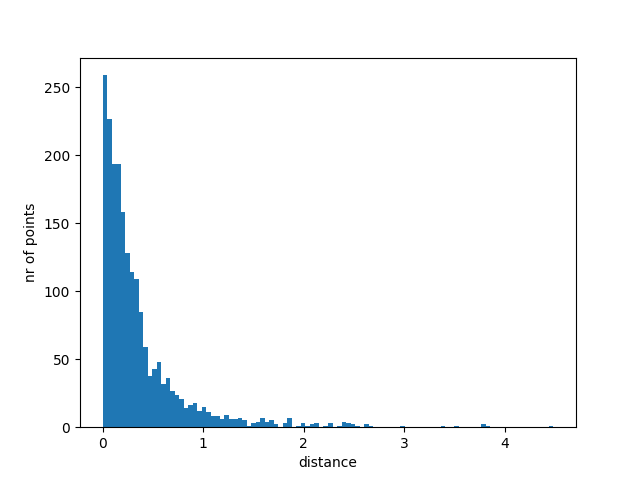

In [8]:
# ------ Your code here ------

# Compute mean epipolar distance
D = compute_epipolar_errors(F, p1, p2)
meanD = np.mean(D)
print(f'mean distance = {meanD}')

# Plot epipolar distances in a histogram
fig5 = plt.figure()  
ax5 = fig5.add_subplot()
ax5.hist(D, bins=100)   # choose number of bins
plt.xlabel("distance")
plt.ylabel("nr of points")
plt.show()

#### Your answer here: 

The mean distance with normalization is: 0.361

### Task 1.4

See what happens if we do everything without normalization (that is, set $N_1=N_2=I$ and run the code again).
What is the mean distance in this case?

|Mv| = 0.5629347767539131
smallest singular value = 0.5629347767539199
mean distance = 0.4878403579998149


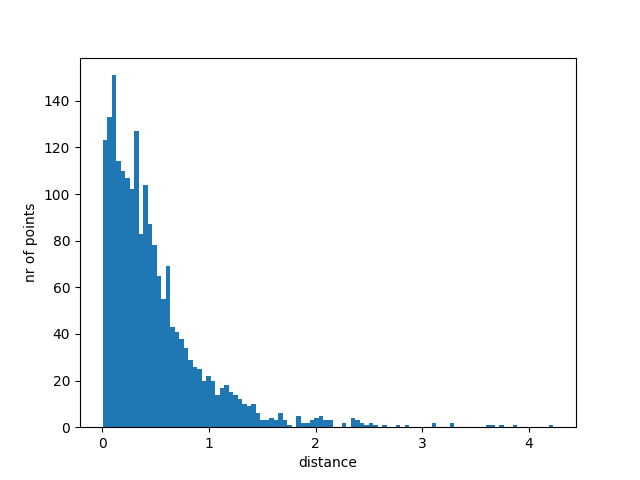

In [9]:
# ------ Your code here ------

# See what happens if N1=N2=I
N1 = np.eye(3)
N2 = np.eye(3)
# Compute mean epipolar distance for this case
F_tilde_notN = estimate_F_DLT(p1, p2)
Un, Sn, Vtn = np.linalg.svd(F_tilde_notN)

S_matrix_N = np.array([[Sn[0], 0, 0],
                     [0, Sn[1], 0],
                     [0, 0, 0]])

F_tilde_det_notN = Un @ S_matrix_N @ Vtn
F_notN = N2.T @ F_tilde_det_notN @ N1


D = compute_epipolar_errors(F_notN, p1, p2)
meanD = np.mean(D)
print(f'mean distance = {meanD}')

# Plot epipolar distances in a histogram
fig6 = plt.figure()  
ax6 = fig6.add_subplot()
ax6.hist(D, bins=100)   # choose number of bins
plt.xlabel("distance")
plt.ylabel("nr of points")
plt.show()

#### Your answer here: 

The mean distance without normalization is: 0.488


#### *Theoretical exercise 5* (see pdf)

# The Essential Matrix

#### *Theoretical exercise 6* (see pdf)

## Computer Exercise 2


### Task 2.1

The file `compEx2data.mat` contains the calibration matrix $K$ for the two images in Computer Exercise 1. 
Normalize the image points using the inverse of $K$.

Set up the matrix $M$ in the eight point algorithm, and solve the homogeneous least squares system using SVD. Check that the minimum singular value and $Mv$ are both small. You can of course re-use function `estimate_F_DLT`.

Construct the essential matrix from the solution $v$. Don't forget to make sure that $E$ has two equal singular values and the third one zero.
As the essential matrix is a homogeneous entity, scale does not matter, but for grading purposes, please also make sure that the two non-zero singular values are both equal to 1.
Check that the epipolar constraints $\tilde{x}_2^T E\tilde{x}_1 = 0$ are roughly fulfilled.

In [10]:
def enforce_essential(E_approx):
    '''
    E_approx - Approximate Essential matrix (3x3)
    '''
    U, S, Vt = np.linalg.svd(E_approx)
    det = np.linalg.det(np.matmul(U,Vt))
    print(f'Determinant = {det}')
    return det

In [29]:
# ------ Your code here ------
data_e = sp.io.loadmat('data/compEx2data.mat')
K = data_e['K']

# Normalize the image points 
p1n = np.linalg.inv(K) @ p1
p2n = np.linalg.inv(K) @ p2

# Set up the matrix M in eight point algorithm and solve for v
F_tilde = estimate_F_DLT(p1n, p2n)

# Check that minimum singular value and Mv both are small

# Construct essential matrix from v (Ensuring that the two non-zero singular values are both equal to 1
U, S, Vt = np.linalg.svd(F_tilde)
D = np.diag(np.array([1, 1, 0]))
E_approx = U @ D @ -Vt
# Check that epipolar constraints are roughly fulfilled
print(E_approx.shape)
print(p2n[:,1].T @ E_approx @ p1n[:,1]) 

|Mv| = 0.006626799894543115
smallest singular value = 0.006626799894543251
(3, 3)
0.0014834781768609416


### Task 2.2

Compute the fundamental matrix for the un-normalized coordinate system from the essential matrix and compute the epipolar lines $l = F  x_1$. Pick 20 of the detected points in the second image
at random and plot these in the same figure as the image. Also plot the corresponding epipolar lines in the same figure using the function `rital`.

Compute the distance between the points and their corresponding epipolar lines and plot these in a histogram with 100 bins. 
**How does this result compare to the corresponding result in Computer Exercise 1?** If the errors are higher, remember that we are dealing with noisy measurements, and for the essential matrix we enforce more constraints than for the fundamental matrix. Write the following function that will be helpful for the rest of the course.

In [12]:
# Note that we in this case have K1=K2=K

def convert_E_to_F(E,K1,K2):
    '''
    A function that gives you a fundamental matrix from an essential matrix and the two calibration matrices
    E - Essential matrix (3x3)
    K1 - Calibration matrix for the first image (3x3)
    K2 - Calibration matrix for the second image (3x3)
    '''
    F_from_e = np.linalg.inv(K2.T) @ E @ np.linalg.inv(K1)
    return F_from_e

In [30]:
# test code, loading sift points instead of supplied points 
from pathlib import Path 
cwd = Path.cwd()
data = sp.io.loadmat('data/kronan_points.mat')
x1 = data['x1']
x2 = data['x2']
ones = np.ones((1, x1.shape[1]))

x1_h = np.vstack((x1, ones)) # append one to third coordinate
x2_h = np.vstack((x2, ones))

p1n = np.linalg.inv(K) @ x1_h
p2n = np.linalg.inv(K) @ x2_h

F_tilde = estimate_F_DLT(p1n, p2n)

# Check that minimum singular value and Mv both are small

# Construct essential matrix from v (Ensuring that the two non-zero singular values are both equal to 1
U, S, Vt = np.linalg.svd(F_tilde)
D = np.diag(np.array([1, 1, 0]))
E_approx = U @ D @ -Vt

|Mv| = 0.3383769350005029
smallest singular value = 0.33837693500050287


[[ 2.33064000e-09 -1.73246966e-07  7.29932183e-05]
 [ 1.73454681e-07  2.91610769e-09 -1.52605793e-04]
 [-7.47730826e-05  1.33670429e-04  7.35348091e-03]]
[[1.45560e+02 4.02100e+02 5.23440e+02 ... 3.26900e+02 3.68100e+02
  1.10660e+02]
 [4.66020e+02 5.15020e+02 3.25080e+02 ... 4.74540e+02 1.18608e+03
  1.70200e+02]
 [1.00000e+00 1.00000e+00 1.00000e+00 ... 1.00000e+00 1.00000e+00
  1.00000e+00]]


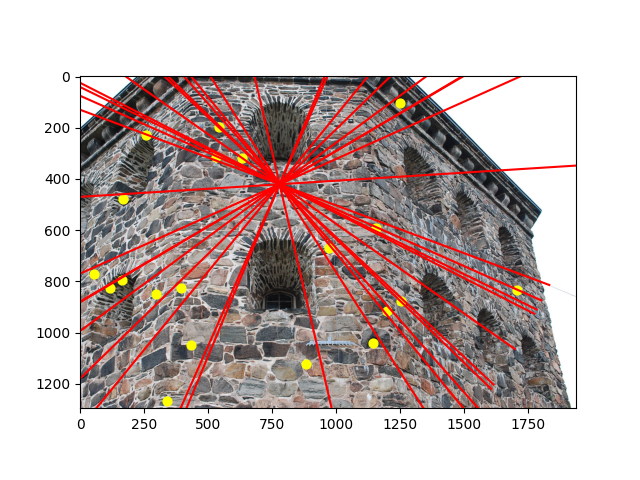

mean distance = 23.55251786676259


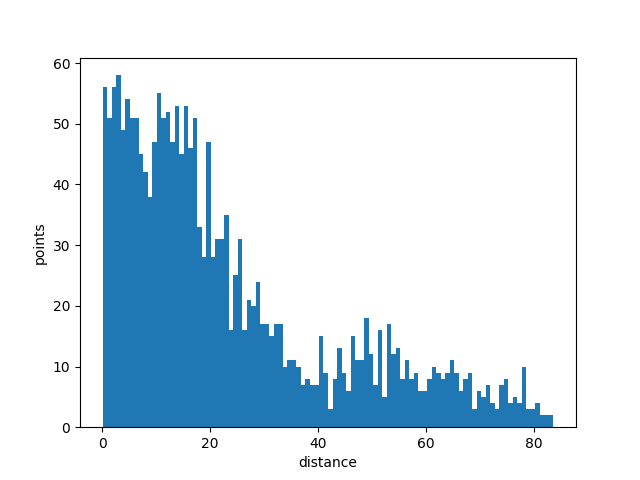

In [31]:
# ------ Your code here ------
f = plt.figure()
a = f.add_subplot()
a.imshow(img2)

F_from_e = convert_E_to_F(E_approx,K,K) # Compute F from E
print(F_from_e)
print(p1)

De = np.zeros(p1.shape[1])
for idx, p in enumerate(random_points):
    l2 = np.matmul(F_from_e, p1[:,p]).reshape(1,3) # Compute epipolar lines
    rital(l2) # Plot 20 lines 
    a.scatter(p2[:,p][0], p2[:,p][1], color='yellow', s = 40) # Plot 20 points

    # Compute distance between points and lines
    x0, y0, _ = p2[:,p]
    l2_1, l2_2, l2_3 = l2[0]
plt.show()

for i in range(p1.shape[1]):
    l2 = np.matmul(F_from_e, p1[:,i]).reshape(1,3) # Compute epipolar lines

    # Compute distance between points and lines
    x0, y0, _ = p2[:,i]
    l2_1, l2_2, l2_3 = l2[0]
    
    temp = np.abs(l2_1*x0 + l2_2*y0 + l2_3) 
    temp2 = np.sqrt(l2_1**2 + l2_2**2) 
    d = temp/temp2
    De[i] = d

meanDe = np.mean(De)
print(f'mean distance = {meanDe}')

fig7 = plt.figure()  
ax7 = fig7.add_subplot()
ax7.hist(De, bins=100)   
plt.xlabel("distance")
plt.ylabel("points")
plt.show()


### Your answer here: 

**How does this result compare to the corresponding result in Computer Exercise 1?** : The average distance from point to line is 2.08 which is higher than previous exercises. 
#

#### *Theoretical exercise 7* (see pdf)

## Computer Exercise 3


### Task 3.1

\begin{equation}
P_2 = [UWV^T \ u_3] \text{ or } [UWV^T \ -u_3]  \text{ or }
[UW^TV^T \ u_3]  \text{ or } [ UW^TV^T \ -u_3 ]
\end{equation}


For the essential matrix obtained in Computer Exercise 2 compute the four camera solutions above (make sure that `det(U*V') > 0`; otherwise set `V = -V`).

Write a function that does this for you, it will also be useful in the future. The output `P` should contain all four solutions.

In [14]:
def extract_P_from_E(E):
     '''
    A function that extract the four P2 solutions given above
    E - Essential matrix (3x3)
    P - Array containing all four P2 solutions (4x3x4) (i.e. P[i,:,:] is the ith solution) 
    '''
     U, S, Vt = np.linalg.svd(E)
     det = enforce_essential(E)
     if det < 0:
          Vt = -Vt
     W = np.array([[0, -1, 0],
          [1, 0, 0],
          [0, 0, 1]])
     u3 = U[:,2]
     Pa = np.hstack((U @ W @ Vt, u3.reshape(3,1))) 
     Pb = np.hstack((U @ W @ Vt, -u3.reshape(3,1))) 
     Pc = np.hstack((U @ W.T @ Vt, u3.reshape(3,1))) 
     Pd = np.hstack((U @ W.T @ Vt, -u3.reshape(3,1))) 
     P = np.array([Pa, Pb, Pc, Pd])
     return P

In [15]:
# Extract P2 from E 
P1 = np.hstack((np.eye(3), np.zeros((3,1))))
P2_arr = extract_P_from_E(E_approx)

Determinant = 0.9999999999999999


Triangulate the points using DLT for each of the four camera solutions, and determine for which of the solutions the points are in front of the cameras.
In this exercise, you may expect to have only one solution for which all the 3D points are in front of both cameras. But in general, since there is noise involved it might not be possible to find a solution with all points in front of the cameras. (In that case the solution with the highest number of points in front of the cameras needs to be selected.)

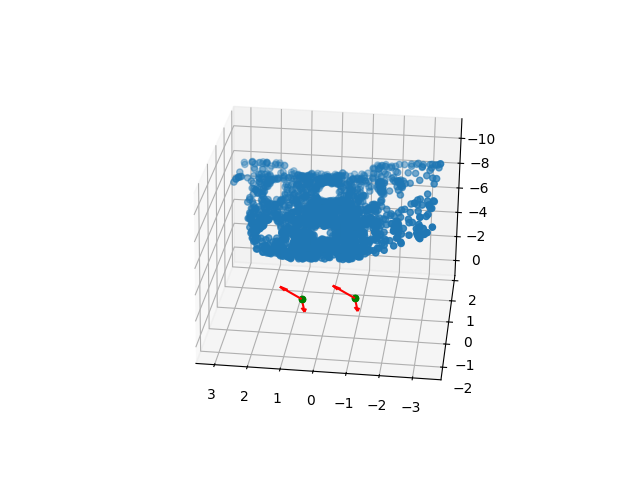

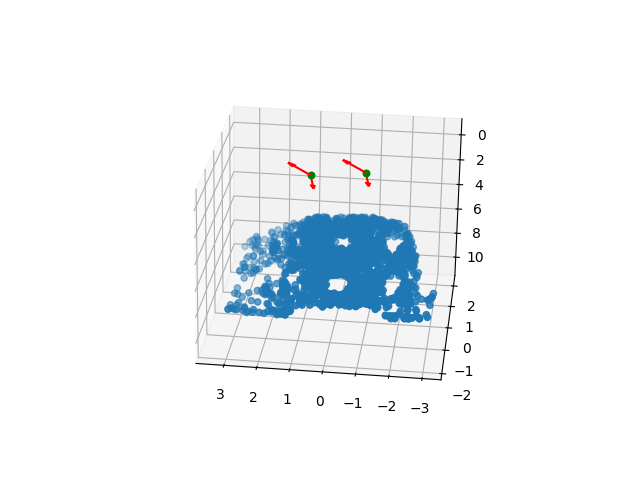

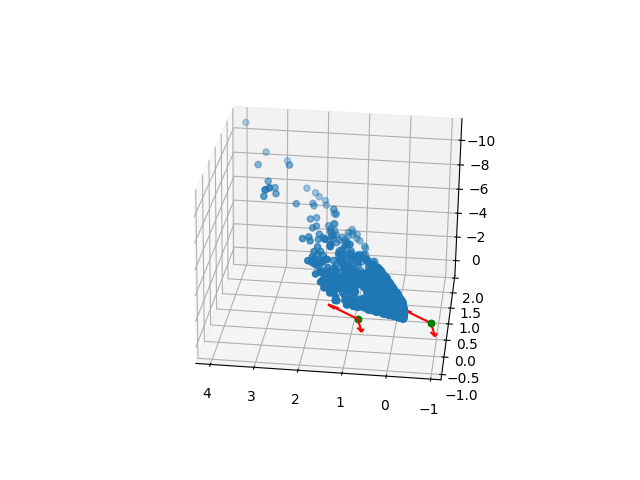

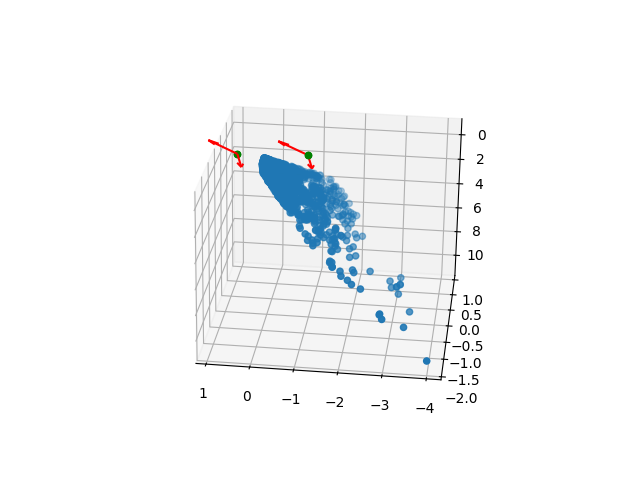

Solution (U @ W @ Vt, -u3) seem to have the points in front of the camera.


In [16]:
'''
To triangulate we need:
    * Two sets of points that correspond to the same scene point.
    * The camera matrices of the two points 
'''
# Triangulate the points using DLT for each of the four camera solutions
#print(p1n) # nomalized with inverse of K, homogeneous
#print(p1_norm) # normalized with N, homogeneous
#print(p1) # camera coordinates, homogeneous

nr_of_points = p1.shape[1]
X_tot_arr = []

for P2 in P2_arr:
    X_arr = np.zeros((4, nr_of_points))
    for p in range(nr_of_points):
        u1, v1, _ = p1n[:,p] # normalized with K^-1, homogeneous, z coordinate 1
        u2, v2, _ = p2n[:,p] # normalized with K^-1, homogeneous, z coordinate 1

        M = np.vstack((u1 * P1[2] - P1[0], v1 * P1[2] - P1[1], u2 * P2[2] - P2[0],  v2 * P2[2] - P2[1]))

        _, _, Vt = np.linalg.svd(M)
        X = Vt[-1]
        X = X / X[-1]
        X = X.reshape(4,)
        X_arr[:,p] = X
    X_tot_arr.append(X_arr)


fig9 = plt.figure()
ax9 = fig9.add_subplot(projection="3d")
ax9.scatter(X_tot_arr[0][0], X_tot_arr[0][1], X_tot_arr[0][2])
#ax9.view_init(elev=19, azim=105, roll=16)
ax9.view_init(elev=-24, azim=-96, roll=179)
plot_camera(P2_arr[0], 1, ax=ax9)
plot_camera(P2_arr[1], 1, ax=ax9)
plot_camera(P2_arr[2], 1, ax=ax9)
plot_camera(P2_arr[3], 1, ax=ax9)
plt.show()

fig10 = plt.figure()
ax10 = fig10.add_subplot(projection="3d")
ax10.scatter(X_tot_arr[1][0], X_tot_arr[1][1], X_tot_arr[1][2])
ax10.view_init(elev=-24, azim=-96, roll=179)
plot_camera(P2_arr[0], 1, ax=ax10)
plot_camera(P2_arr[1], 1, ax=ax10)
plot_camera(P2_arr[2], 1, ax=ax10)
plot_camera(P2_arr[3], 1, ax=ax10)
plt.show()

fig11 = plt.figure()
ax11 = fig11.add_subplot(projection="3d")
ax11.scatter(X_tot_arr[2][0], X_tot_arr[2][1], X_tot_arr[2][2])
ax11.view_init(elev=-24, azim=-96, roll=179)
plot_camera(P2_arr[0], 1, ax=ax11)
plot_camera(P2_arr[1], 1, ax=ax11)
plot_camera(P2_arr[2], 1, ax=ax11)
plot_camera(P2_arr[3], 1, ax=ax11)
plt.show()

fig12 = plt.figure()
ax12 = fig12.add_subplot(projection="3d")
ax12.scatter(X_tot_arr[3][0], X_tot_arr[3][1], X_tot_arr[3][2])
ax12.view_init(elev=-24, azim=-96, roll=179)
plot_camera(P2_arr[0], 1, ax=ax12)
plot_camera(P2_arr[1], 1, ax=ax12)
plot_camera(P2_arr[2], 1, ax=ax12)
plot_camera(P2_arr[3], 1, ax=ax12)
plt.show()


# Determine for which of the solutions the points are in front of the cameras
print(f'Solution (U @ W @ Vt, -u3) seem to have the points in front of the camera.')

Compute the corresponding camera matrices for the original (un-normalized) coordinate system and plot the image points and the projected 3D-points in the same figure.
**Do the errors look small?**
Verify that the projections are reasonably well aligned with the image points.

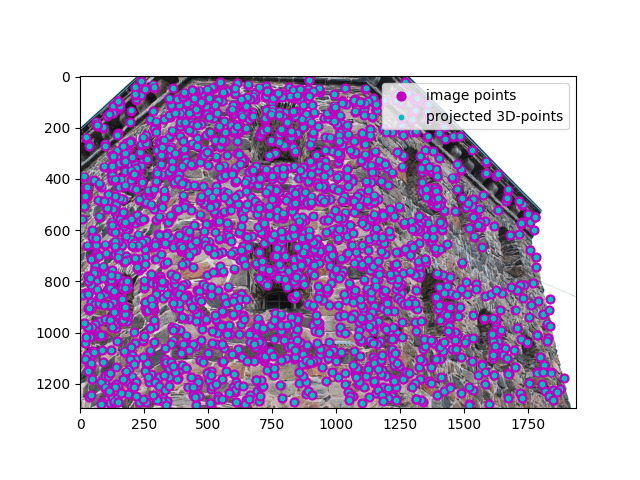

mean error image 2 =  1.0411589395321015


In [17]:
# Compute the corresponding camera matrices for the original (un-normalized) coordinate system 
camera = 0
P1_un_norm = np.matmul(K, P1)
P2_un_norm = np.matmul(K, P2_arr[camera])

# Plot the image points and the projected 3D-points in the same figure 
ff = plt.figure()
aa = ff.add_subplot()
aa.imshow(img2)
err = []
for rp in range(p2.shape[1]):#random_points:
    # extract image and projected points
    xx, yy, _ = p2[:,rp]
    proj_point = np.matmul(P2_un_norm, X_tot_arr[camera][:,rp] )
    xp, yp, _ = proj_point/proj_point[2]

    # Compute errors
    err.append(np.linalg.norm(p2[:,rp] - proj_point/proj_point[2]))

    # plot points
    aa.scatter(xx, yy, color='m', s=40)
    aa.scatter(xp, yp, color='c', s=10)
aa.scatter(xx, yy, color='m', s=40, label='image points') # one extra time for labeling
aa.scatter(xp, yp, color='c', s=10, label='projected 3D-points')
plt.legend()
plt.show()


print("mean error image 2 = ", np.mean(err))
    

Plot the 3D points and camera centers and principal axes in a 3D plot.
**Does it look like you expected it to ?**

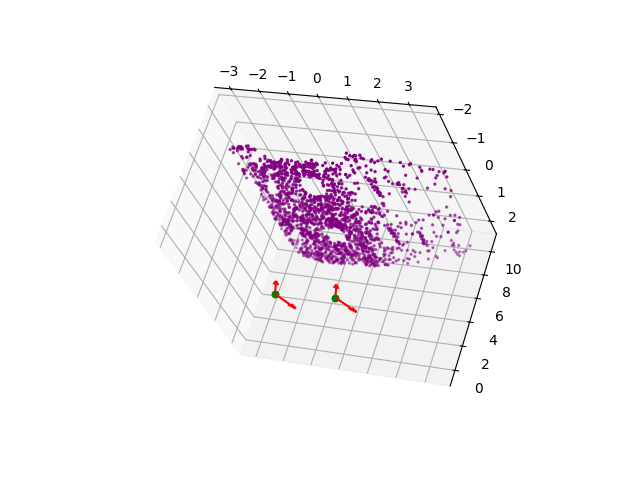

In [18]:
# ------ Your code here ------
camera = 1
P2a_un_norm = np.matmul(K, P2_arr[0])
P2b_un_norm = np.matmul(K, P2_arr[1])
P2c_un_norm = np.matmul(K, P2_arr[2])
P2d_un_norm = np.matmul(K, P2_arr[3])


# Plot the 3D points and camera centers and principal axes in a 3D plot 
fig_final = plt.figure()
ax_final = fig_final.add_subplot(projection='3d')

ax_final.scatter(X_tot_arr[camera][0], X_tot_arr[camera][1], X_tot_arr[camera][2], color='purple', s=2, label='Scene points')
plot_camera(P2a_un_norm, 1, ax=ax_final)
plot_camera(P2b_un_norm, 1, ax=ax_final)
plot_camera(P2c_un_norm, 1, ax=ax_final)
plot_camera(P2d_un_norm, 1, ax=ax_final)
ax_final.view_init(-25, -63, -19)
plt.legend
plt.show()



### Your answer here: 
**Does it look like you expected it to ?**

yes, two camera viewing rays are directed towards the structure.  

**Do the errors look small?**

Yes the errors look smaller than for previous exercises.  
#